device → cuda


/tmp/ipykernel_597090/832666556.py:27: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha_1 = lambda t : torch.tensor(1-t)
/tmp/ipykernel_597090/832666556.py:28: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  alpha_2 = lambda t : torch.tensor(1-t)
/tmp/ipykernel_597090/832666556.py:33: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  gamma_3 = lambda t : torch.tensor(-1 * (1-2*t)**2)
/tmp/ipykernel_597090/832666556.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.deta

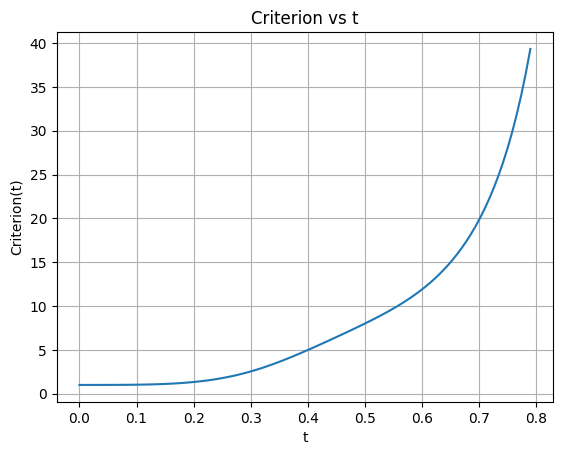

In [47]:

import torch
import matplotlib.pyplot as plt
import numpy as np
import random, os
from datetime import datetime
import os
import torch
import numpy as np
import pandas as pd
from utils.metrics.export import compute_sample_based_metrics
from hcg.interpolant import MLPInstFlexible, run_training_v_s
from hcg.sample_data import sample_checkerboard, make_conditions, sample_data_model1, sample_data_model2, sample_data_model3, ground_truth_hcg, plot_diagnostics
from hcg.hcg import simulate_hcg, simulate_hcg_generalized
from hcg.interpolant import Interpolant as Interpolant
from hcg.interpolant import FlowMatcher as FlowMatcher
from hcg.interpolant import plot_path_trajectories as plot_path_trajectories


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0); random.seed(0); np.random.seed(0)
print("device →", device)

experiment_id = "DivergingChecker"  # Use a fixed ID for reproducibility
if not os.path.exists(experiment_id):
    os.makedirs(experiment_id)

alpha_1 = lambda t : torch.tensor(1-t)
alpha_2 = lambda t : torch.tensor(1-t)
alpha_3 = lambda t : torch.tensor((1-t) * (t + (1-2*t)**2))
gamma_1 = lambda t : torch.tensor(1)
gamma_2 = lambda t : torch.tensor(1)
gamma_3 = lambda t : -torch.tensor(1)
gamma_3 = lambda t : torch.tensor(-1 * (1-2*t)**2)

alpha_list = [alpha_1, alpha_2, alpha_3]
gamma_list = [gamma_1, gamma_2, gamma_3]

Criterion = lambda t: sum([ gamma_list[i](t) / (alpha_list[i](t))**2 for i in range(len(alpha_list)) ])

# plot Criterion for t in [0.0:0.01:0.99]
t = torch.linspace(0.0, 0.790, 100)
plt.plot(t.numpy(), Criterion(t).numpy())
# plt.yscale('log')
plt.xlabel('t')
plt.ylabel('Criterion(t)')
plt.title('Criterion vs t')
plt.grid(True)
plt.savefig(os.path.join(experiment_id, "Criterion_plot.png"))
plt.show()

# print when Criterion = 0
for i in range(len(t)-1):
    if Criterion(t[i]) > 0 and Criterion(t[i+1]) < 0:
        print("Criterion = 0 at t =", t[i].item())
        break
for i in range(len(t)-1):
    if Criterion(t[i]) < 0 and Criterion(t[i+1]) > 0:
        print("Criterion = 0 at t =", t[i].item())
        break

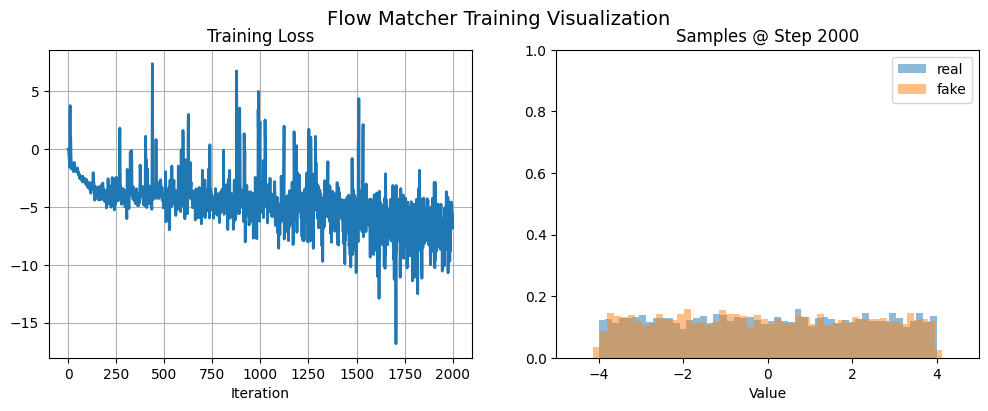

In [ ]:
u_theta = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X
s_theta = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X

# --- USAGE SCENARIO 1: Default Linear Interpolant ---
print("--- Using Default Linear Interpolant ---")
default_interpolant = Interpolant() # Or just pass None
fm_trainer_default = FlowMatcher(u_theta, s_theta, interpolant=default_interpolant)
fm_trainer_default.train(sample_data_model3, n_iters=2000) # Using few iterations for demo
torch.save(u_theta.state_dict(), f"{experiment_id}/u_model3_X_default_alpha.pth")
torch.save(s_theta.state_dict(), f"{experiment_id}/s_model3_X_default_alpha.pth")


u_theta = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X
s_theta = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device) # X


# # --- USAGE SCENARIO 2: Custom Non-Linear Interpolant ---
print("\n--- Using Custom Non-Linear Interpolant ---")
# wait 2 seconds to separate the two trainings
import time; time.sleep(2)

def custom_alpha_t(t):
    # return (1.0 - t) * torch.pow(1.0 - 2.0 * t, 2)
    return (1.0 - t) * torch.pow(t + (1.0 - 2 * t) , 2)

def custom_d_alpha_t(t):
    # return -5.0 + 16.0 * t - 12.0 * t**2
    return -4.0 + 14.0 * t - 12.0 * t**2

def custom_beta_t(t):
    return t

def custom_d_beta_t(t):
    return torch.ones_like(t)

custom_interpolant = Interpolant(
    alpha_t=custom_alpha_t,
    beta_t=custom_beta_t,
    d_alpha_t=custom_d_alpha_t,
    d_beta_t=custom_d_beta_t
)
fm_trainer_custom = FlowMatcher(u_theta, s_theta, interpolant=custom_interpolant)
fm_trainer_custom.train(sample_data_model3, n_iters=2000)
torch.save(u_theta.state_dict(), f"{experiment_id}/u_model3_X_different_alpha_t.pth")
torch.save(s_theta.state_dict(), f"{experiment_id}/s_model3_X_different_alpha_t.pth")

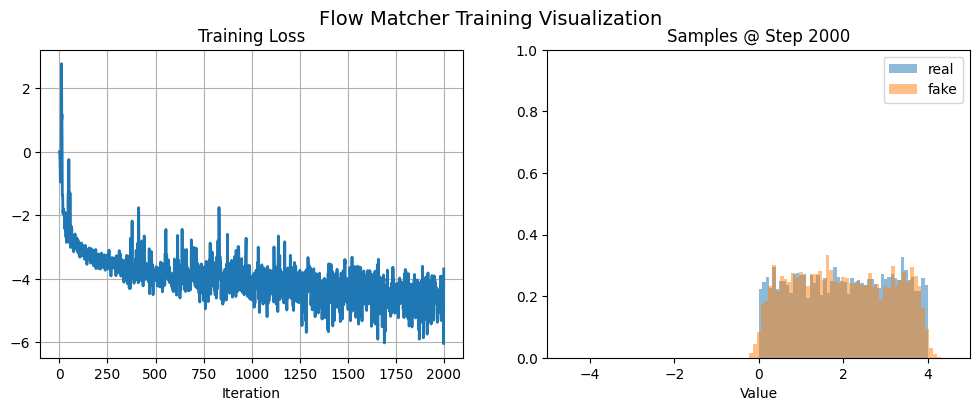

In [15]:
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device) # X | A
default_interpolant = Interpolant() # Or just pass None
fm_trainer_default = FlowMatcher(u_model1, s_model1, interpolant=default_interpolant)
fm_trainer_default.train(sample_data_model1, n_iters=2000, plot_cond_val=1.0) # Using few iterations for demo
torch.save(u_model1.state_dict(), f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")
torch.save(s_model1.state_dict(), f"{experiment_id}/s_model1_X_given_A_default_alpha.pth")

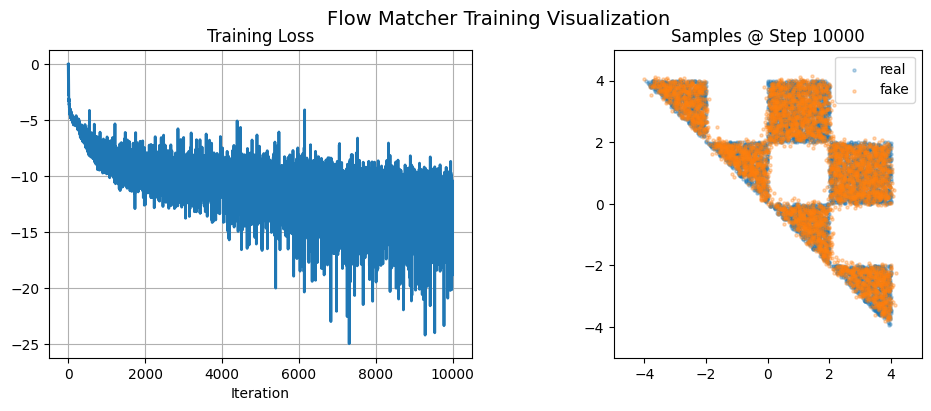

In [16]:
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device) # X, Y | B
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device) # X, Y | B
default_interpolant = Interpolant() # Or just pass None
fm_trainer_default = FlowMatcher(u_model2, s_model2, interpolant=default_interpolant)
fm_trainer_default.train(sample_data_model2, n_iters=10000, plot_cond_val=1.0) # Using few iterations for demo
torch.save(u_model2.state_dict(), f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")
torch.save(s_model2.state_dict(), f"{experiment_id}/s_model2_XY_given_B_default_alpha.pth")

# Default (1-t)

Models loaded.


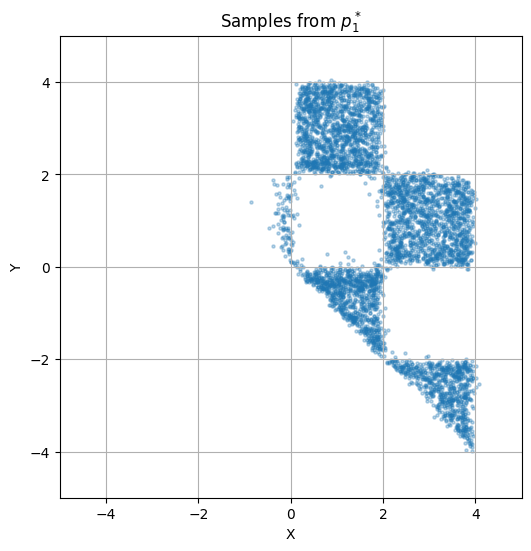

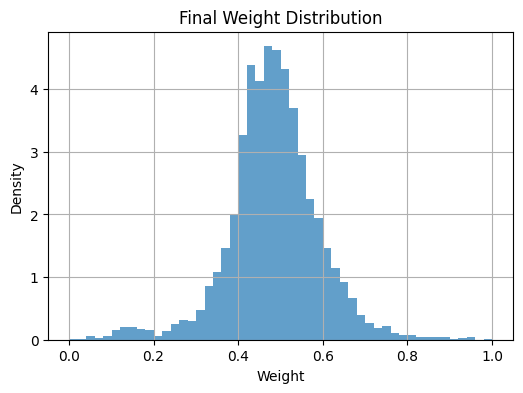

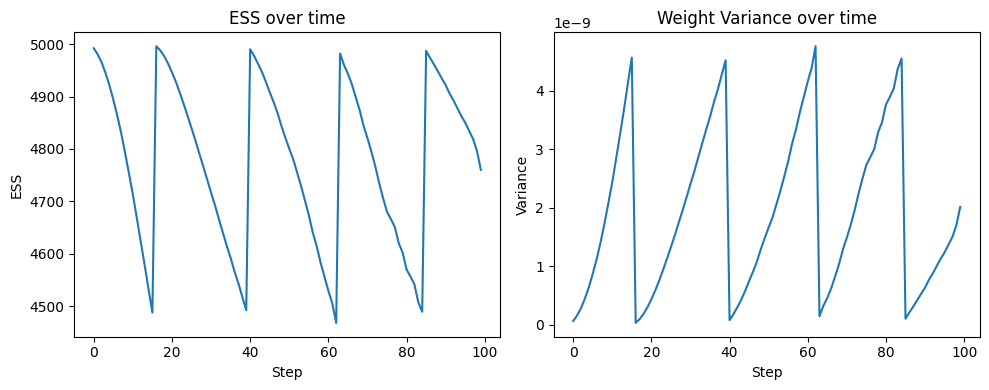

In [43]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X_default_alpha.pth")); u_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")


gamma_1 = lambda t: torch.ones_like(t)
gamma_2 = lambda t: -torch.ones_like(t)
gamma_3 = lambda t: torch.ones_like(t)
d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: torch.zeros_like(t)
d_gamma_3 = lambda t: torch.zeros_like(t)



x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    # v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/same_alphas_constant_gammas")

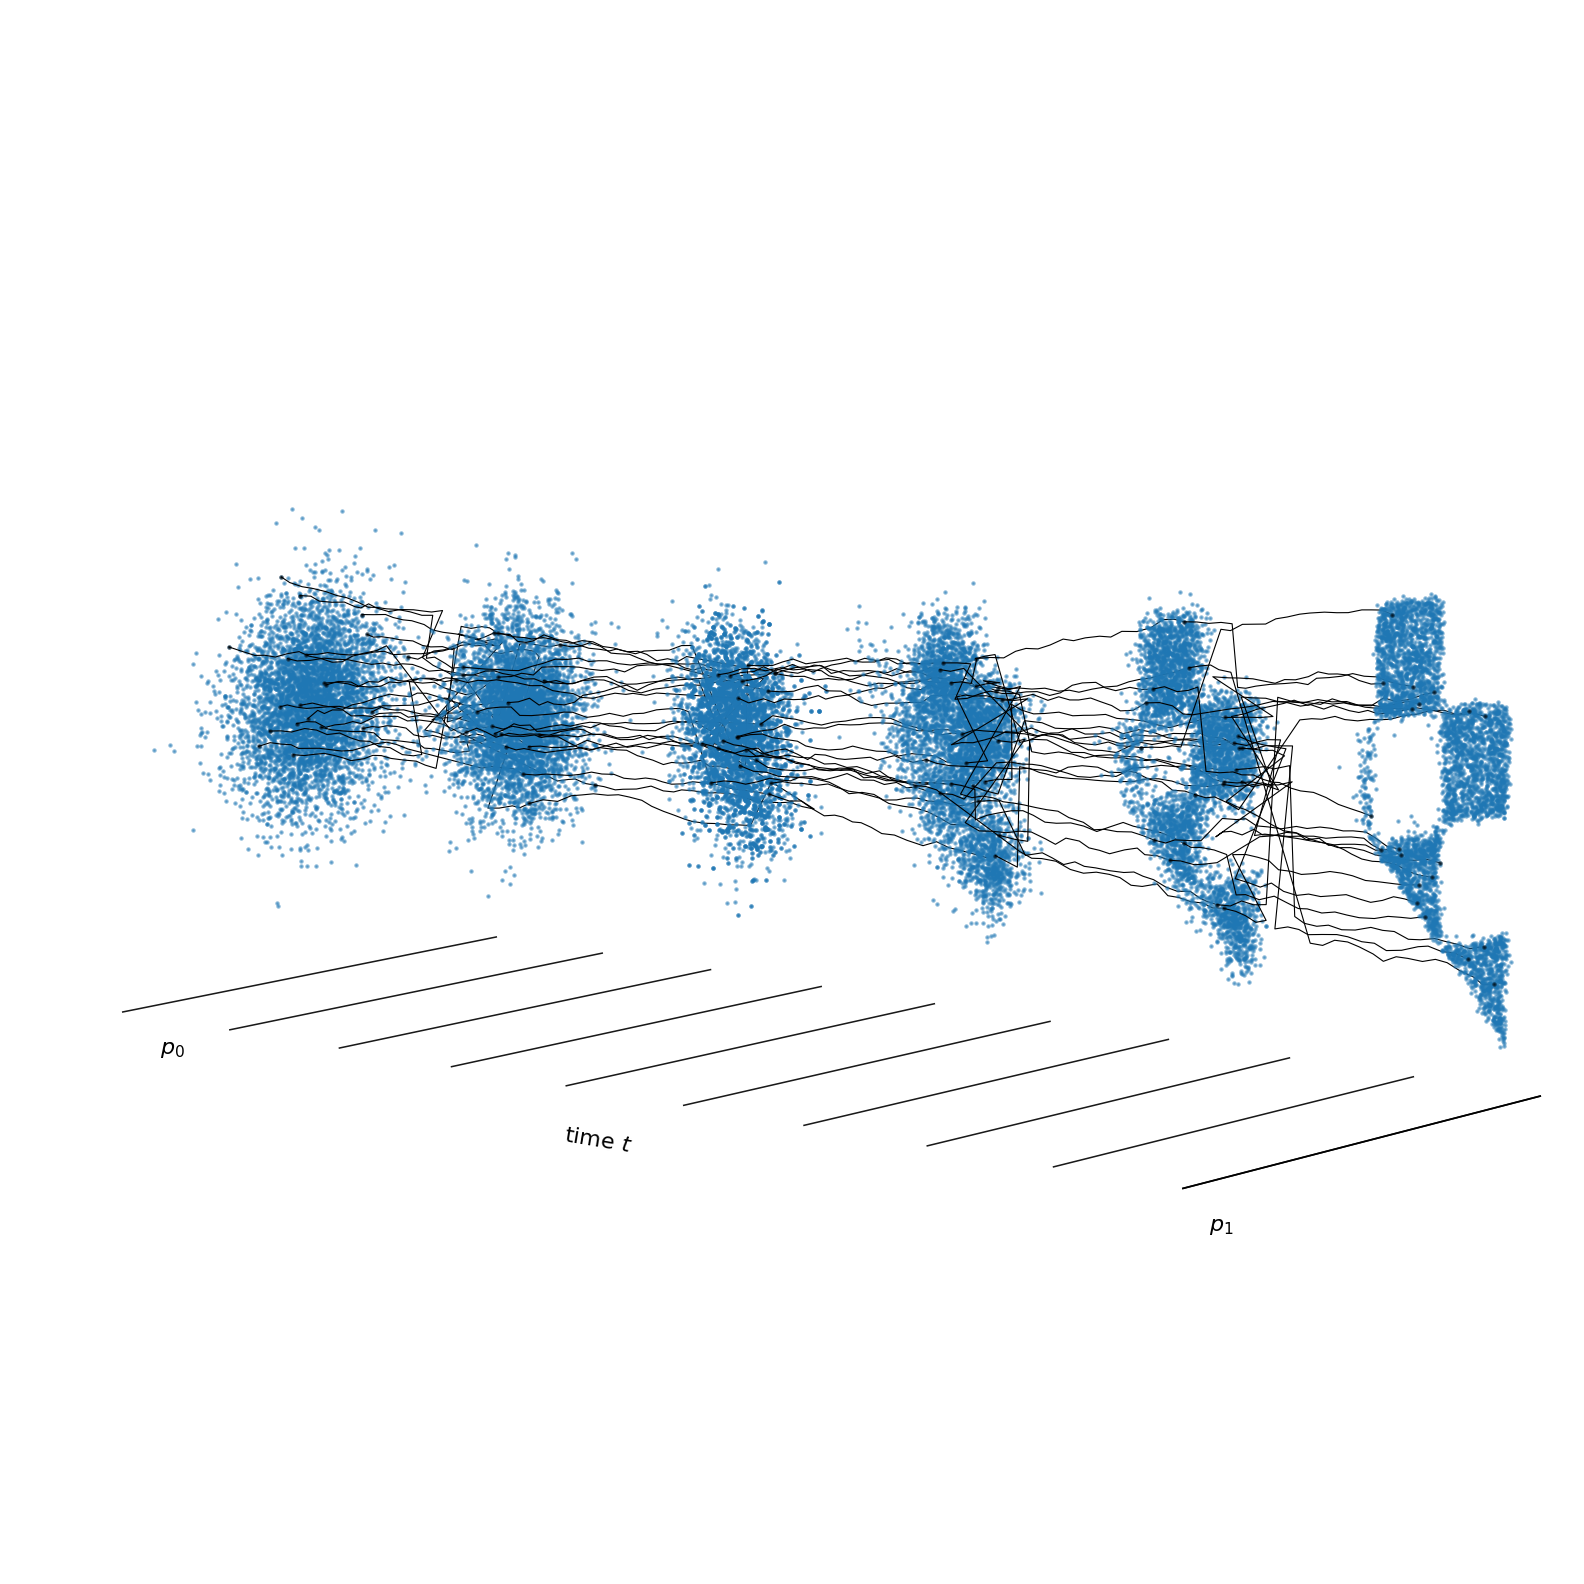

In [44]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="same_alphas_constant_gammas", deg=-50)

Models loaded.


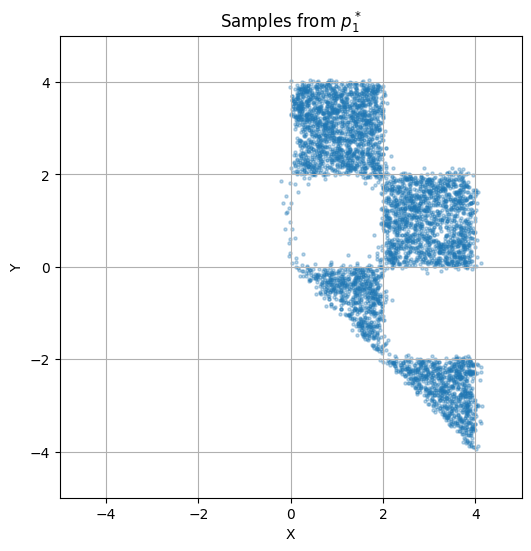

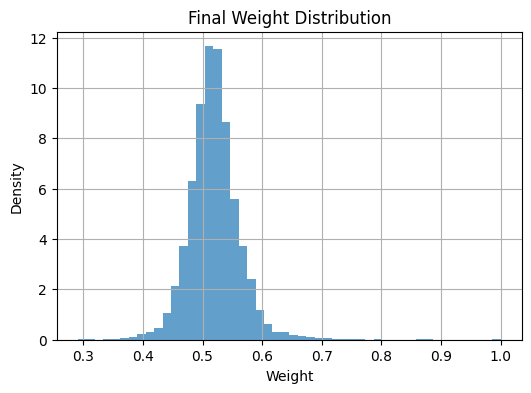

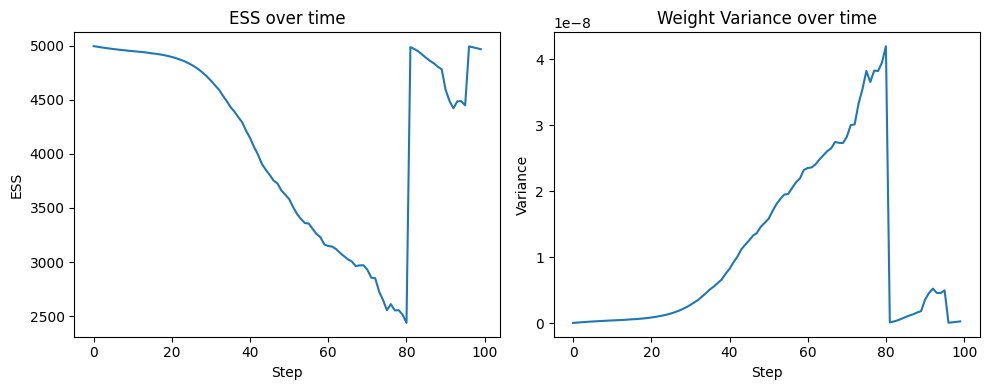

In [ ]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A_default_alpha.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B_default_alpha.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X_default_alpha.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X_default_alpha.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
# def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
# def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
# def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    dim_list=[1, 1, 2],  # dims for q^1(X|A), q^2(X), q^3(Z|B)
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star = lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # v_star = v1
    # v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.5,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/tmp")

# Different Scheduling for $\alpha_t$, same constant $\gamma_i$'s

Models loaded.


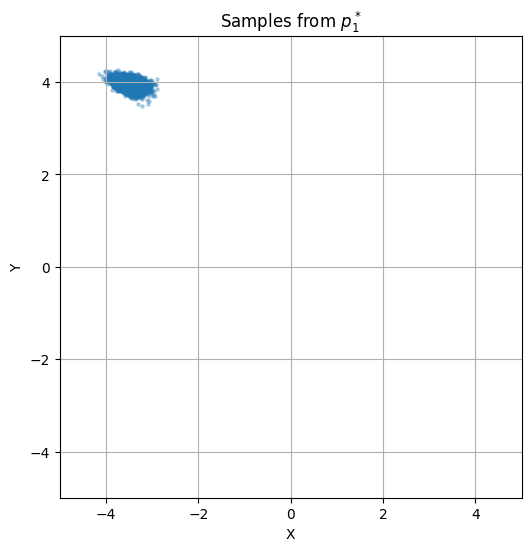

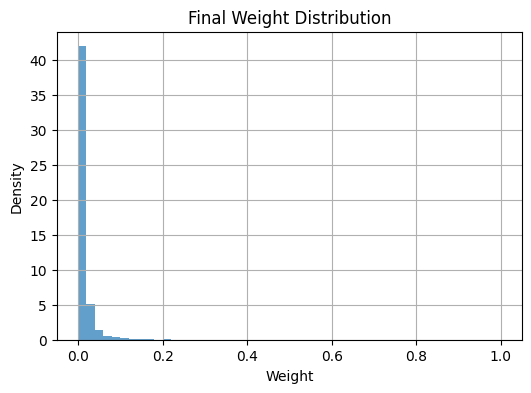

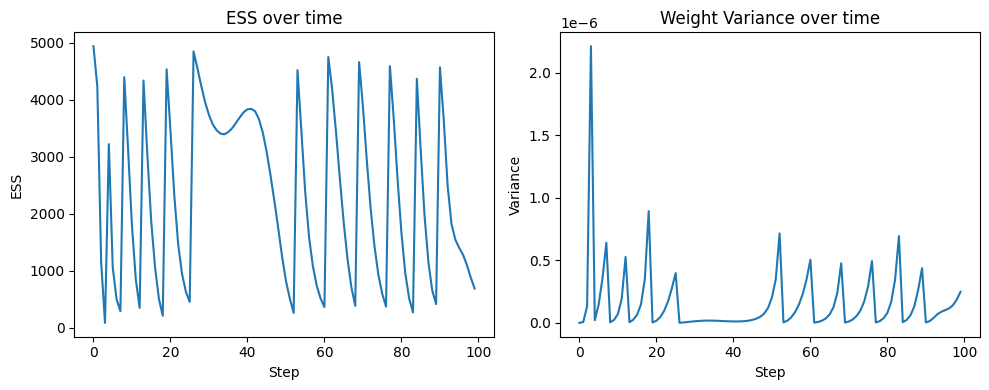

In [ ]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A_default_alpha.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B_default_alpha.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X_different_alpha_t.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X_different_alpha_t.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
# def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
# def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
# def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")

x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[1, -1, 1],     # from log-weight increment in simulate_hcg
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    # v_star = lambda z, t: torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # v_star = v1
    v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/different_alpha_constant_gammas")

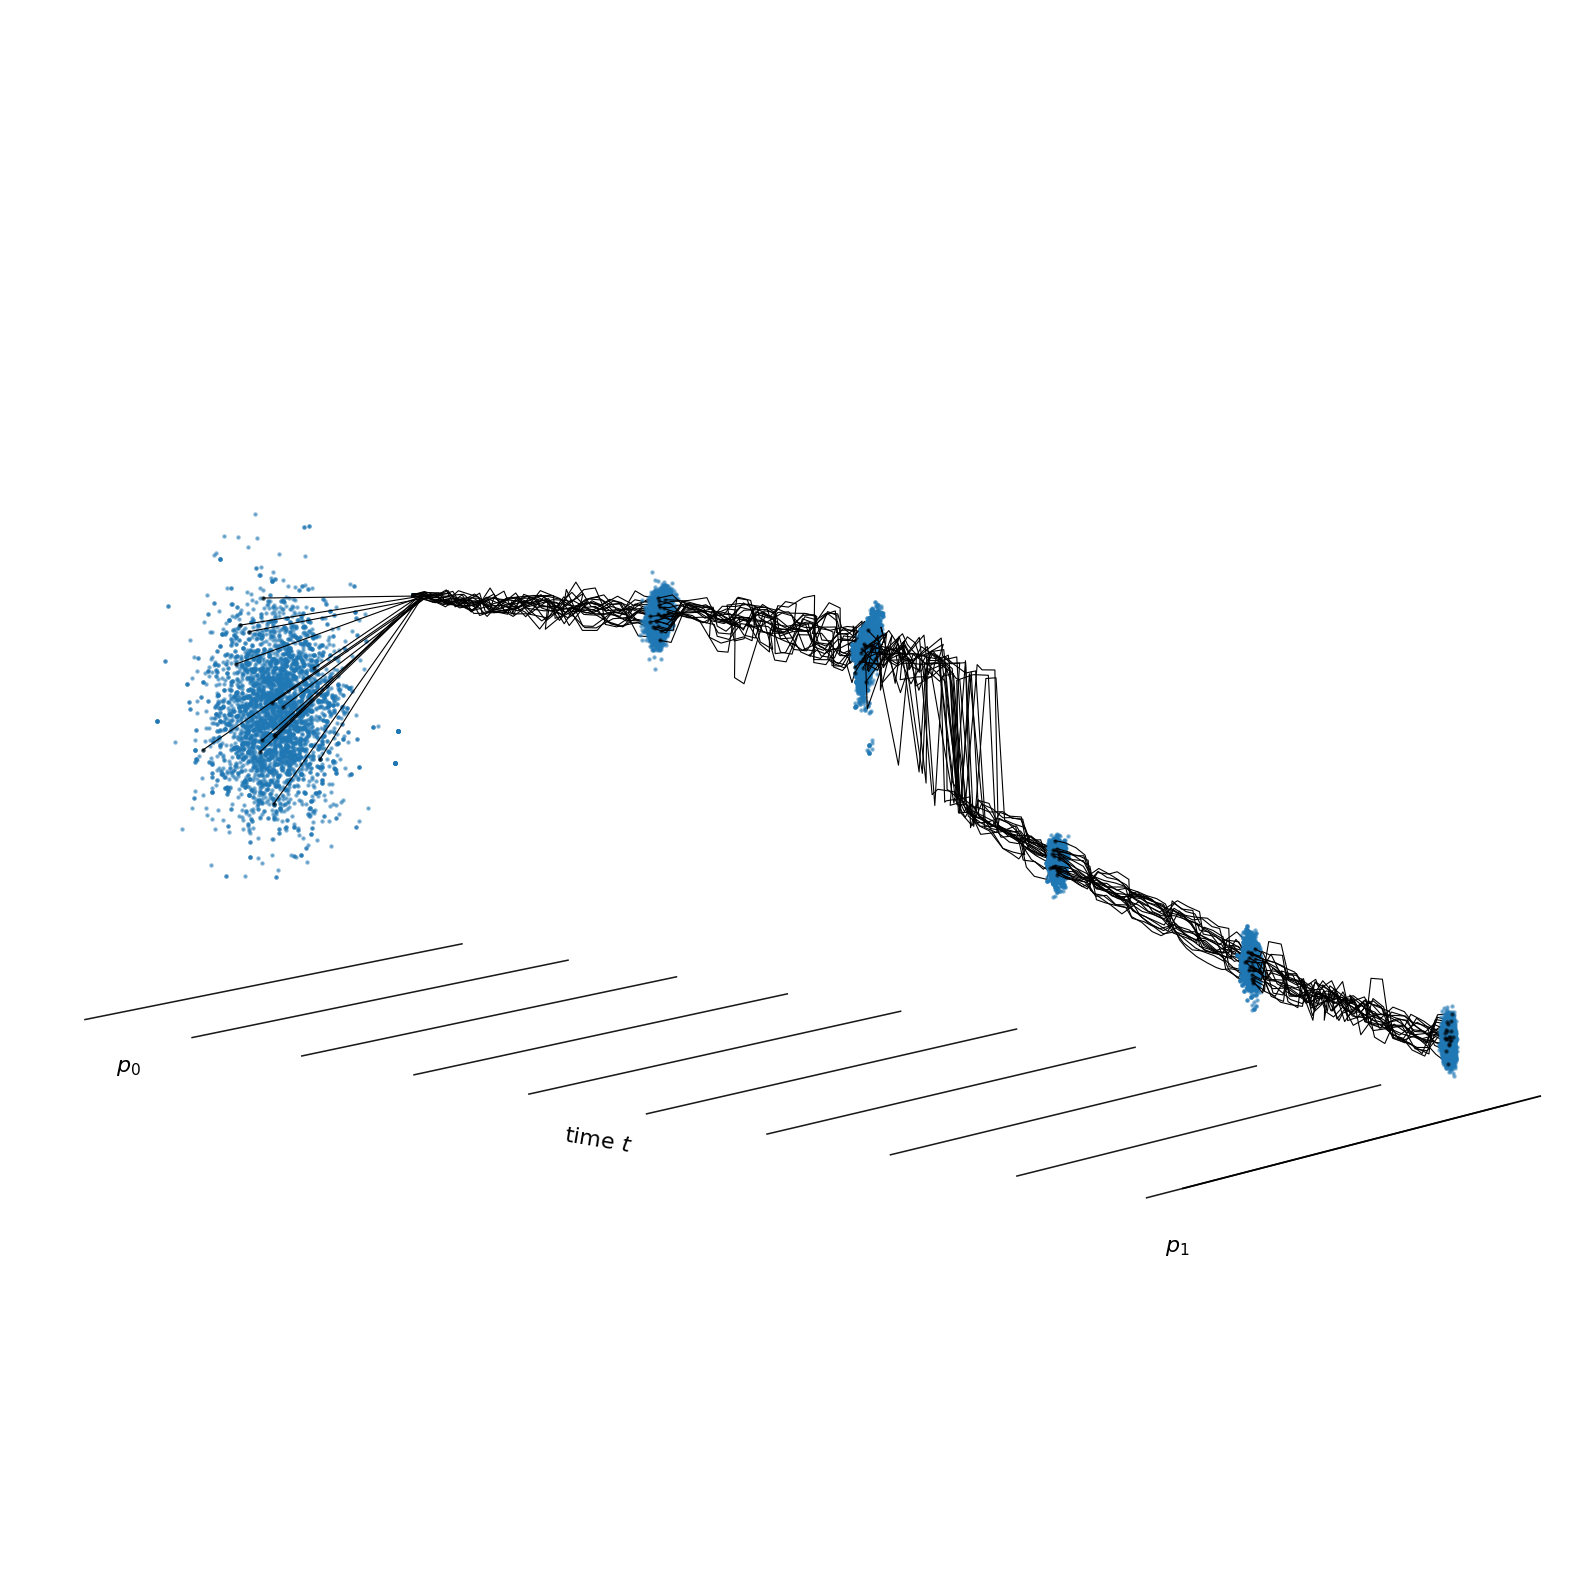

In [42]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="different_alphas_constant_gammas", deg=-50)

Models loaded.


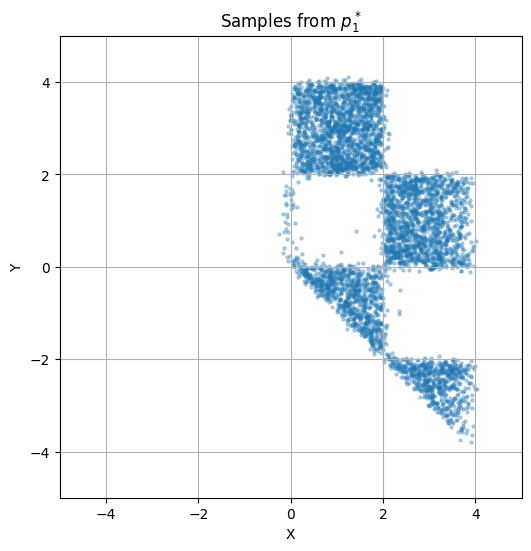

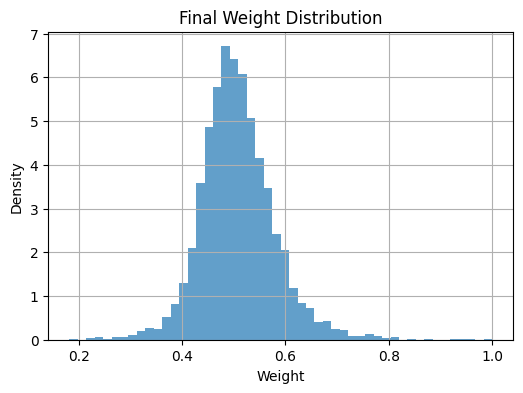

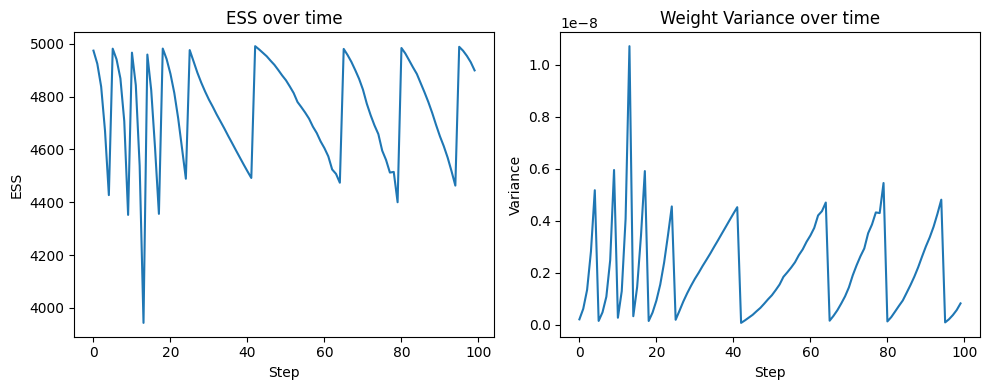

In [38]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A_default_alpha.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B_default_alpha.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X_different_alpha_t.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X_different_alpha_t.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
# def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
# def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
# def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")


gamma_1 = lambda t: torch.ones_like(t)
gamma_2 = lambda t: -1 * (1 - 2 * t)**2
gamma_3 = lambda t: torch.ones_like(t)
d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: 4 * (1 - 2 * t)
d_gamma_3 = lambda t: torch.zeros_like(t)



x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    # v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.9,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/different_alphas_adaptive_gammas")

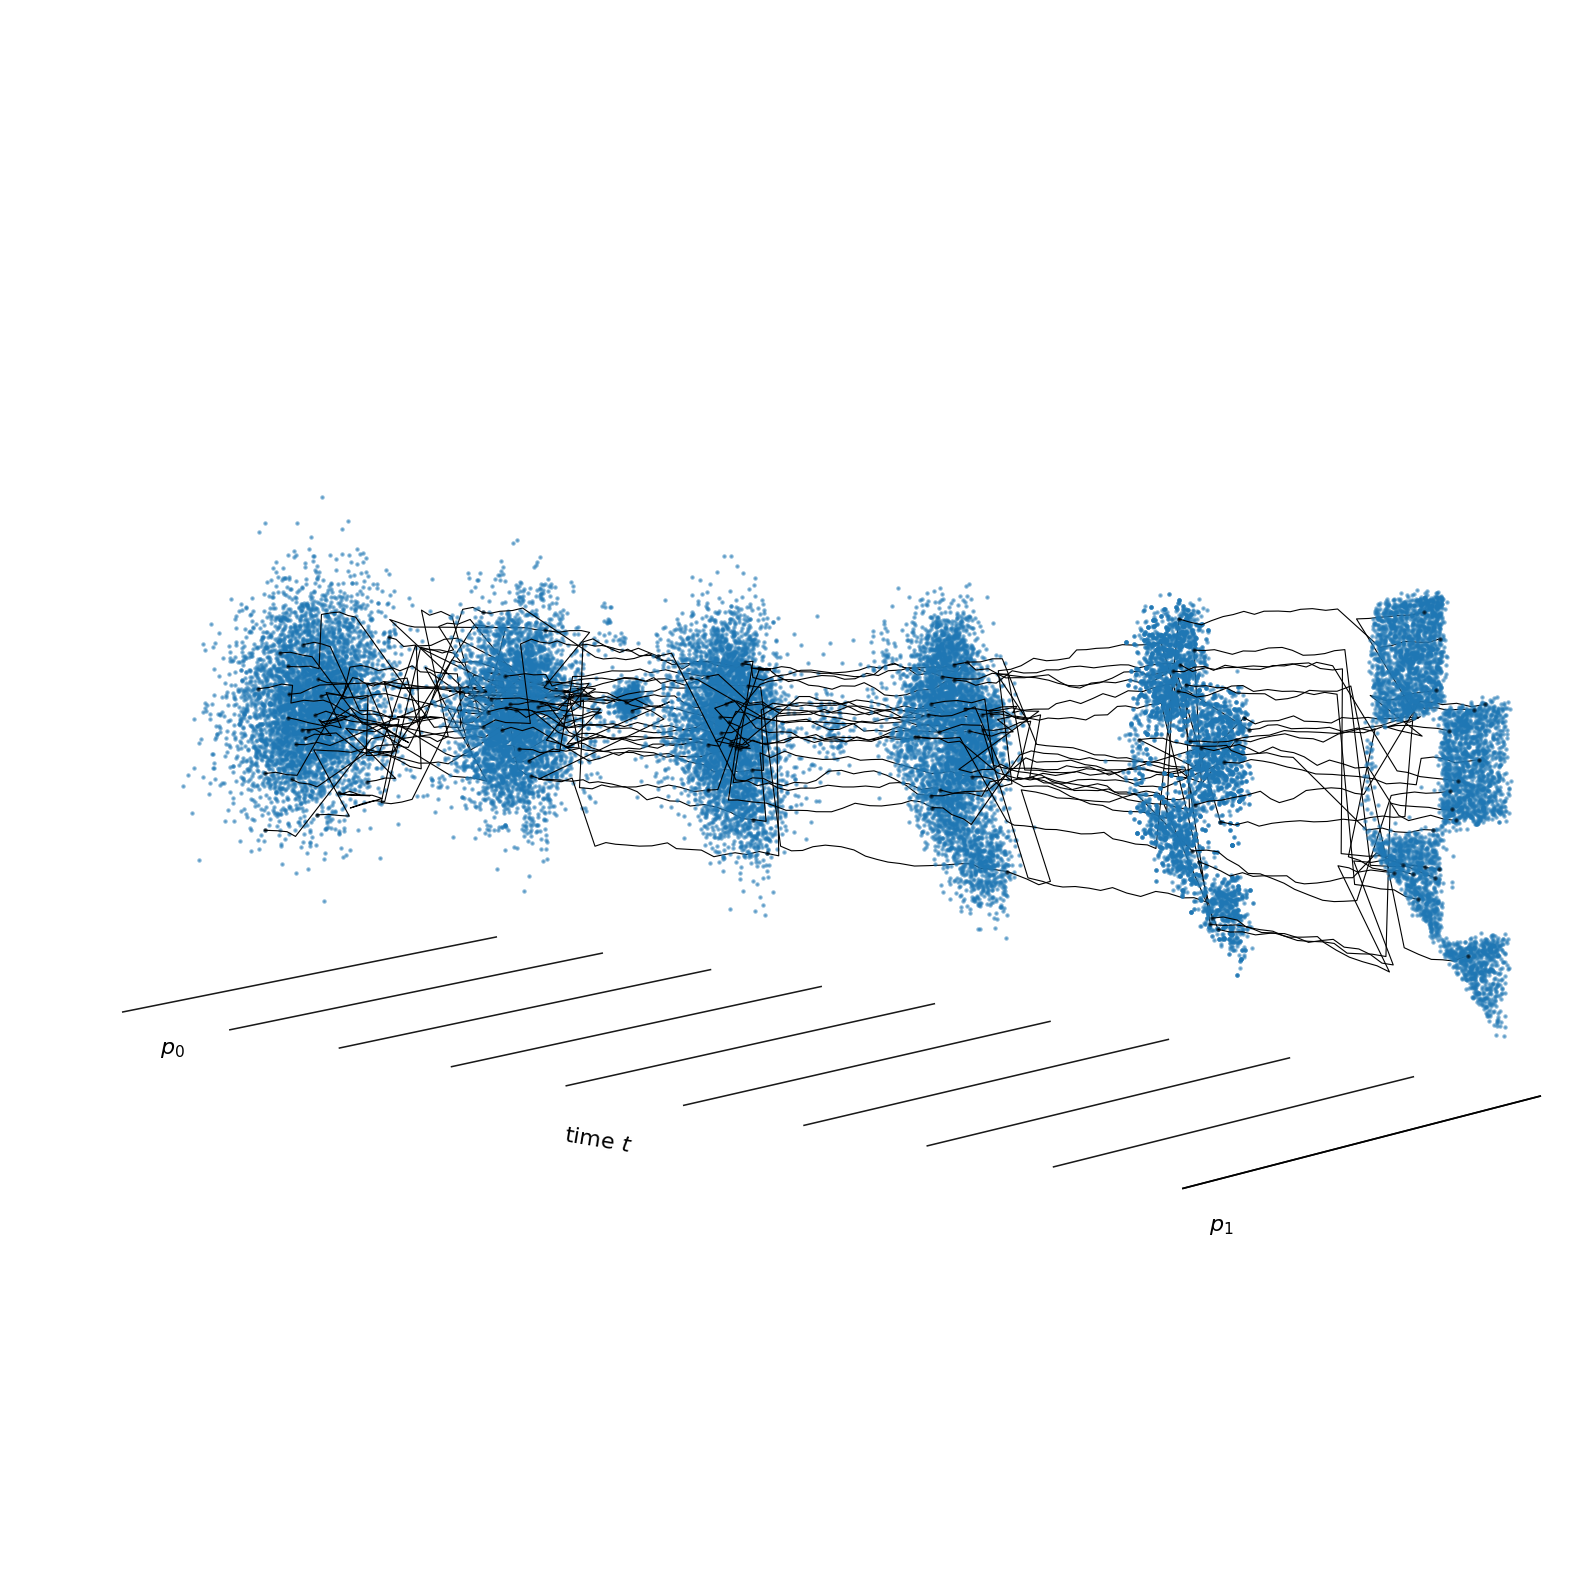

In [39]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=None, experiment_id=experiment_id, name="different_alphas_adaptive_gammas", deg=-50)

Models loaded.


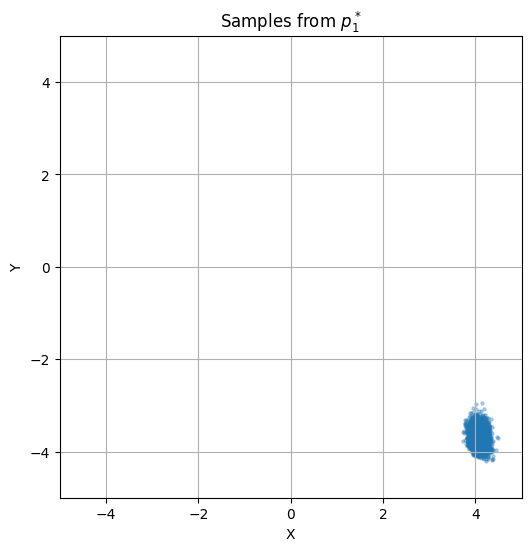

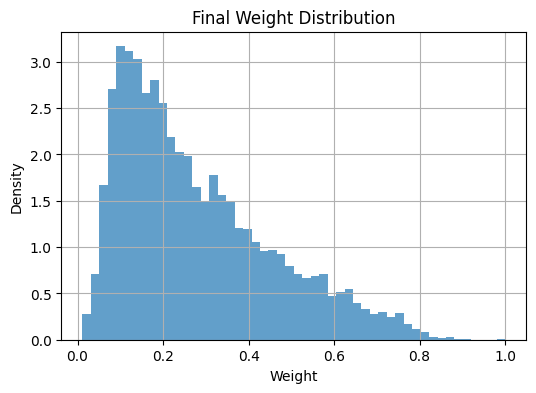

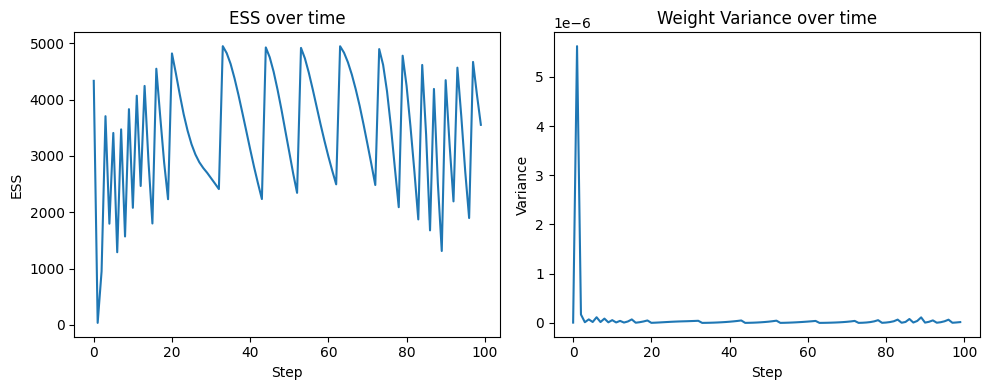

In [20]:
bs = 5000
u_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); u_model1.load_state_dict(torch.load(f"{experiment_id}/u_model1_X_given_A_default_alpha.pth")); u_model1.eval()
s_model1 = MLPInstFlexible(z_dim=1, cond_dim=1, width=256, depth=4, output_dim=1).to(device); s_model1.load_state_dict(torch.load(f"{experiment_id}/s_model1_X_given_A_default_alpha.pth")); s_model1.eval()
u_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); u_model2.load_state_dict(torch.load(f"{experiment_id}/u_model2_XY_given_B_default_alpha.pth")); u_model2.eval()
s_model2 = MLPInstFlexible(z_dim=2, cond_dim=1, width=256, depth=4, output_dim=2).to(device); s_model2.load_state_dict(torch.load(f"{experiment_id}/s_model2_XY_given_B_default_alpha.pth")); s_model2.eval()
u_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); u_model3.load_state_dict(torch.load(f"{experiment_id}/u_model3_X_different_alpha_t.pth")); u_model3.eval()
s_model3 = MLPInstFlexible(z_dim=1, cond_dim=0, width=256, depth=4, output_dim=1).to(device); s_model3.load_state_dict(torch.load(f"{experiment_id}/s_model3_X_different_alpha_t.pth")); s_model3.eval()

def v1_fn(x, t, A): return u_model1(x, t, A)
def s1_fn(x, t, A): return s_model1(x, t, A)
# def s1_fn(x, t, A): return (v1_fn(x, t, A) * t - x) / (1 - t + 1e-8)
def v2_fn(x, t): return u_model3(x, t)
def s2_fn(x, t): return s_model3(x, t)
# def s2_fn(x, t): return (v2_fn(x, t) * t - x) / (1 - t + 1e-8)
def v3_fn(z, t, B): return u_model2(z, t, B)
def s3_fn(z, t, B): return s_model2(z, t, B)
# def s3_fn(z, t, B): return (v3_fn(z, t, B) * t - z) / (1 - t + 1e-8)
def sigma_fn(t): return 0.5 * torch.ones_like(t)
print("Models loaded.")


gamma_1 = lambda t: torch.ones_like(t)
gamma_2 = lambda t: -torch.ones_like(t)
gamma_3 = lambda t: torch.ones_like(t)
d_gamma_1 = lambda t: torch.zeros_like(t)
d_gamma_2 = lambda t: torch.zeros_like(t)
d_gamma_3 = lambda t: torch.zeros_like(t)



x0 = torch.randn(bs, 2).to("cuda")  # (X, Y) sample
A, B = 1, 1  # Conditioning values

samples, logw_final, logw_history, sample_history, resample_history = simulate_hcg_generalized(
    x0=x0, 
    v_fn_list=[
        lambda x, t: v1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # v1(X|A)
        lambda x, t: v2_fn(x[:, :1], t),                                                 # v2(X)
        lambda x, t: v3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # v3(Z|B)
    ],
    s_fn_list=[
        lambda x, t: s1_fn(x[:, :1], t, torch.full((x.size(0), 1), A, device=x.device)), # s1(X|A)
        lambda x, t: s2_fn(x[:, :1], t),                                                 # s2(X)
        lambda x, t: s3_fn(x, t, torch.full((x.size(0), 1), B, device=x.device))         # s3(Z|B)
    ],
    gamma_list=[gamma_1, gamma_2, gamma_3],
    d_gamma_list=[d_gamma_1, d_gamma_2, d_gamma_3],
    proj_list=[
        lambda z: z[:, :1],    # project to X 
        lambda z: z[:, :1],    # project to X
        lambda z: z            # identity for Z
    ],
    emb_list=[
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda x: torch.cat([x, torch.zeros(x.size(0), 1, device=x.device)], dim=1),  # embed X→Z
        lambda z: z  # identity
    ],
    sigma_fn=sigma_fn,
    v_star = lambda z, t: v3_fn(z,t, torch.full((z.size(0),1), B, device=z.device)), # torch.cat([v1_fn(z[:, :1], t, torch.full((z.size(0), 1), A, device=z.device)), torch.zeros(z.size(0), 1, device=z.device)], dim=1) - torch.cat([v2_fn(z[:, :1], t), torch.zeros(z.size(0), 1, device=z.device)], dim=1) + 
    # v_star= lambda z, t: v3_fn(z, t, torch.full((z.size(0), 1), B, device=z.device)), 
    t0=0.0, t1=1.0, n_steps=100,
    device="cuda",
    resample=True,
    ess_threshold=0.5,
    print_resample_history=True
)
samples = samples.cpu().numpy()
plot_diagnostics(samples, logw_final, logw_history, save_name=f"{experiment_id}/different_alphas_constant_gammas")

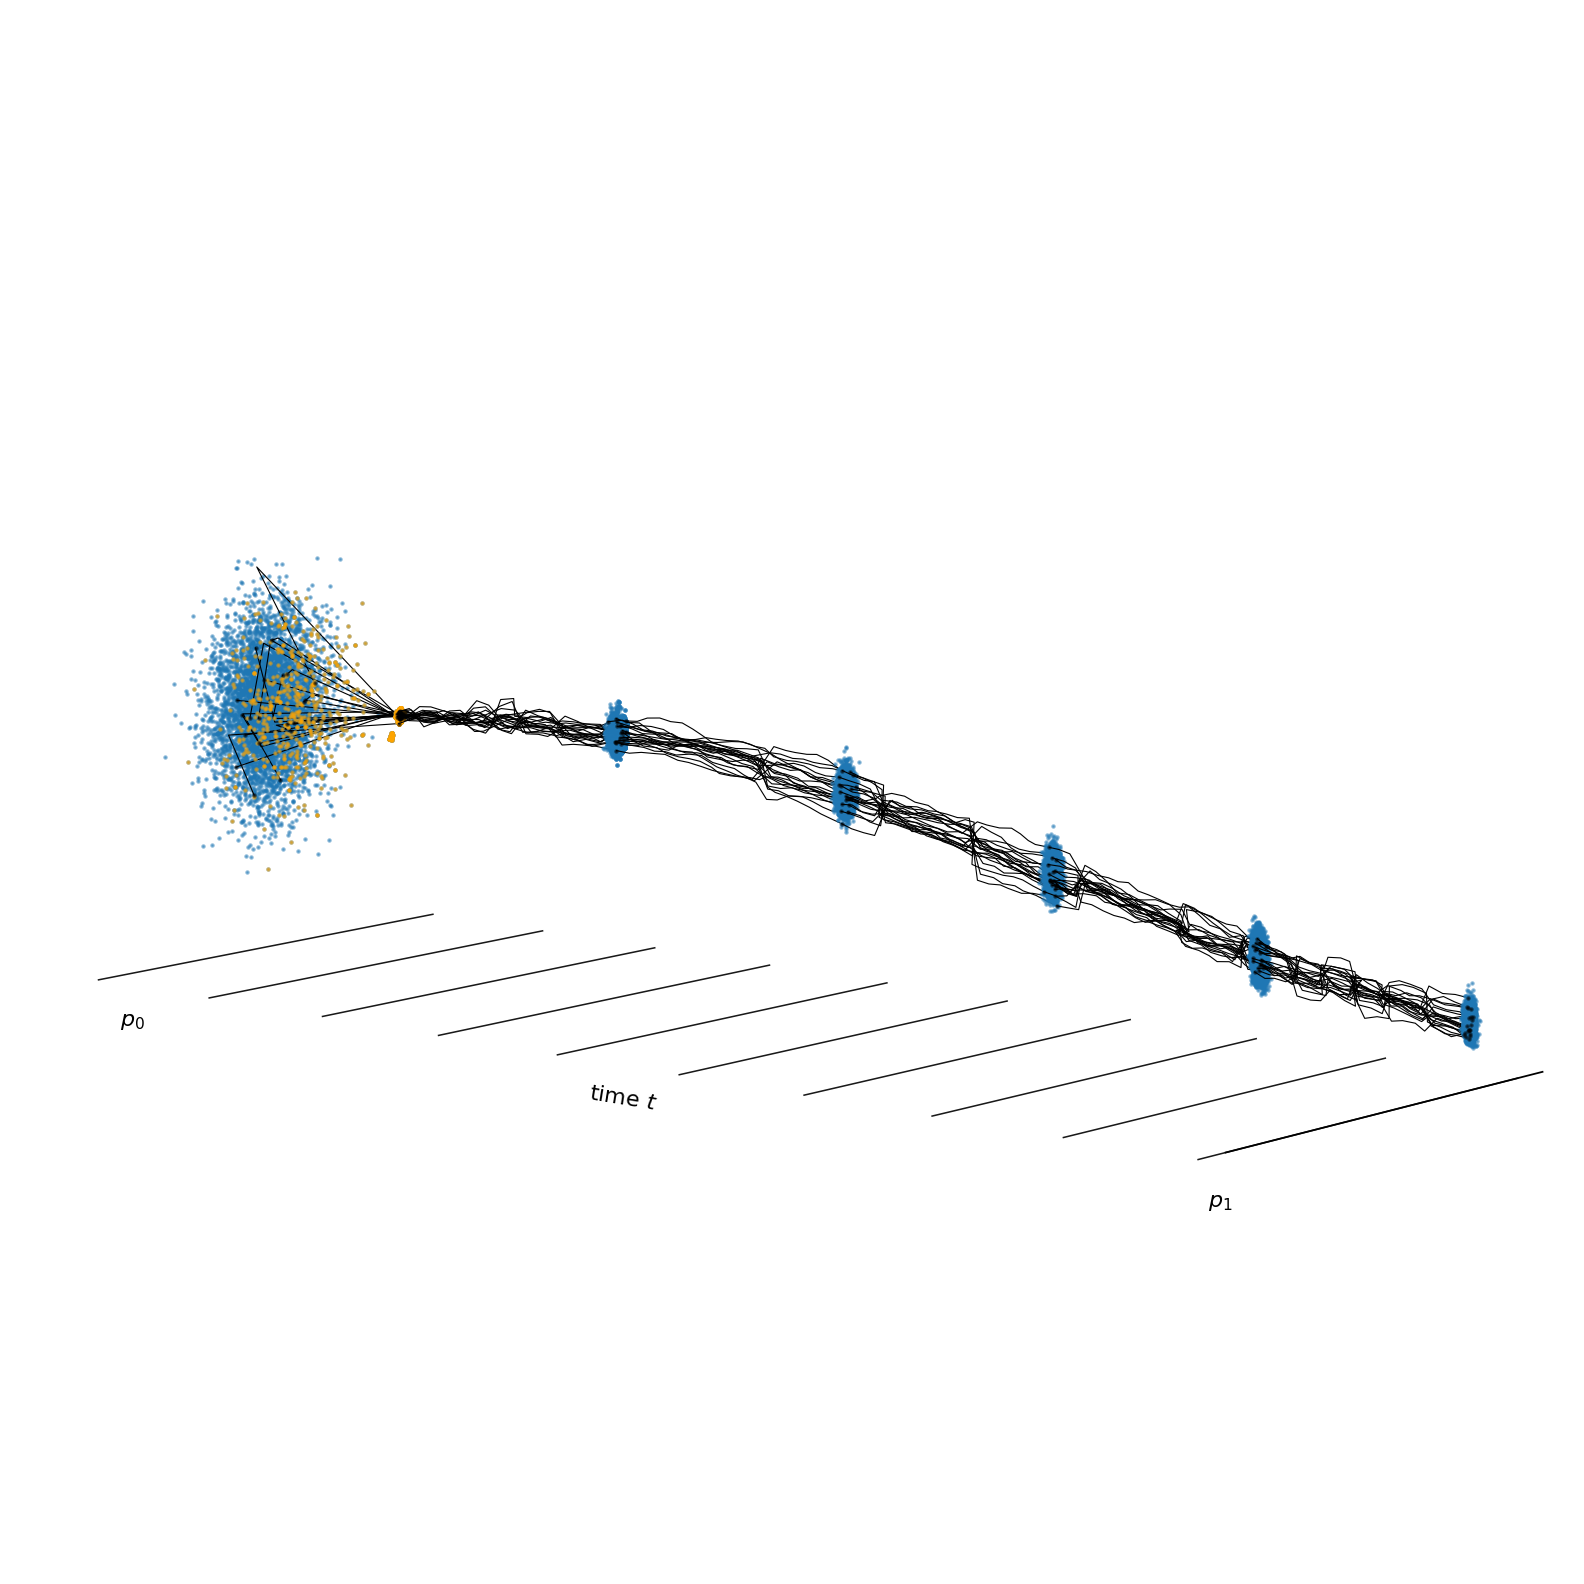

In [21]:
plot_path_trajectories(sample_history, n_frame=6, resample_history=resample_history, experiment_id=experiment_id, name="failed_sample_path", deg=-50)